# Gradient Descent: Single Variable

Minimize $f(x) = e^x - \log(x)$ using gradient descent.

**Update rule:** $x_{n+1} = x_n - \alpha \cdot f'(x_n)$

where $\alpha$ is the learning rate and $f'(x) = e^x - \frac{1}{x}$

## Section 1: Setup

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Libraries imported!")

Libraries imported!


## Section 2: Define Function and Gradient

$$f(x) = e^x - \log(x), \quad f'(x) = e^x - \frac{1}{x}$$

In [11]:
def objective_function(x):
    """f(x) = e^x - log(x)"""
    return np.exp(x) - np.log(x)

def gradient(x):
    """f'(x) = e^x - 1/x"""
    return np.exp(x) - 1.0 / x

# Quick test
test_x = 1.0
print(f"f({test_x}) = {objective_function(test_x):.4f}")
print(f"f'({test_x}) = {gradient(test_x):.4f}")

f(1.0) = 2.7183
f'(1.0) = 1.7183


## Section 3: Gradient Descent Algorithm

1. Start with initial $x_0$
2. Repeat: $x_{n+1} = x_n - \alpha \cdot f'(x_n)$
3. Return optimized $x$

In [12]:
def gradient_descent(x_init, learning_rate, num_iterations, gradient_fn, obj_fn):
    """Run gradient descent, return x and f(x) history."""
    history_x = [x_init]
    history_f = [obj_fn(x_init)]
    x = x_init

    for _ in range(num_iterations):
        x = x - learning_rate * gradient_fn(x)
        history_x.append(x)
        history_f.append(obj_fn(x))

    return np.array(history_x), np.array(history_f)

print("Gradient descent function defined!")

Gradient descent function defined!


## Section 4: Run with Different Learning Rates

In [21]:
x_initial = 2.0
num_iterations = 1000
learning_rates = [0.01, 0.05, 0.1]

# Run with different learning rates
results = {}
for lr in learning_rates:
    x_hist, f_hist = gradient_descent(x_initial, lr, num_iterations, gradient, objective_function)
    results[lr] = {'x_history': x_hist, 'f_history': f_hist}
    print(f"α={lr}: final x={x_hist[-1]:.6f}, f(x)={f_hist[-1]:.6f}")

# Optimal value (from fully converged run)
x_optimal = results[0.1]['x_history'][-1]
f_optimal = results[0.1]['f_history'][-1]

# Run with different iteration counts
print()
iteration_counts = [10, 50, 100, 500, 1000]
lr_fixed = 0.05
print(f"Effect of iterations (α={lr_fixed}, optimal x={x_optimal:.6f}, optimal f(x)={f_optimal:.6f}):")
print(f"{'iters':<8} {'final x':<12} {'f(x)':<12} {'x error':<12} {'f(x) error':<12}")
print("-" * 56)
iter_results = {}
for n in iteration_counts:
    xh, fh = gradient_descent(x_initial, lr_fixed, n, gradient, objective_function)
    iter_results[n] = {'x_history': xh, 'f_history': fh}
    x_err = abs(xh[-1] - x_optimal)
    f_err = abs(fh[-1] - f_optimal)
    print(f"{n:<8} {xh[-1]:<12.6f} {fh[-1]:<12.6f} {x_err:<12.6f} {f_err:<12.6f}")

α=0.01: final x=0.567143, f(x)=2.330366
α=0.05: final x=0.567143, f(x)=2.330366
α=0.1: final x=0.567143, f(x)=2.330366

Effect of iterations (α=0.05, optimal x=0.567143, optimal f(x)=2.330366):
iters    final x      f(x)         x error      f(x) error  
--------------------------------------------------------
10       0.706373     2.374239     0.139230     0.043873    
50       0.567146     2.330366     0.000002     0.000000    
100      0.567143     2.330366     0.000000     0.000000    
500      0.567143     2.330366     0.000000     0.000000    
1000     0.567143     2.330366     0.000000     0.000000    


## Section 5: Visualize the Optimization

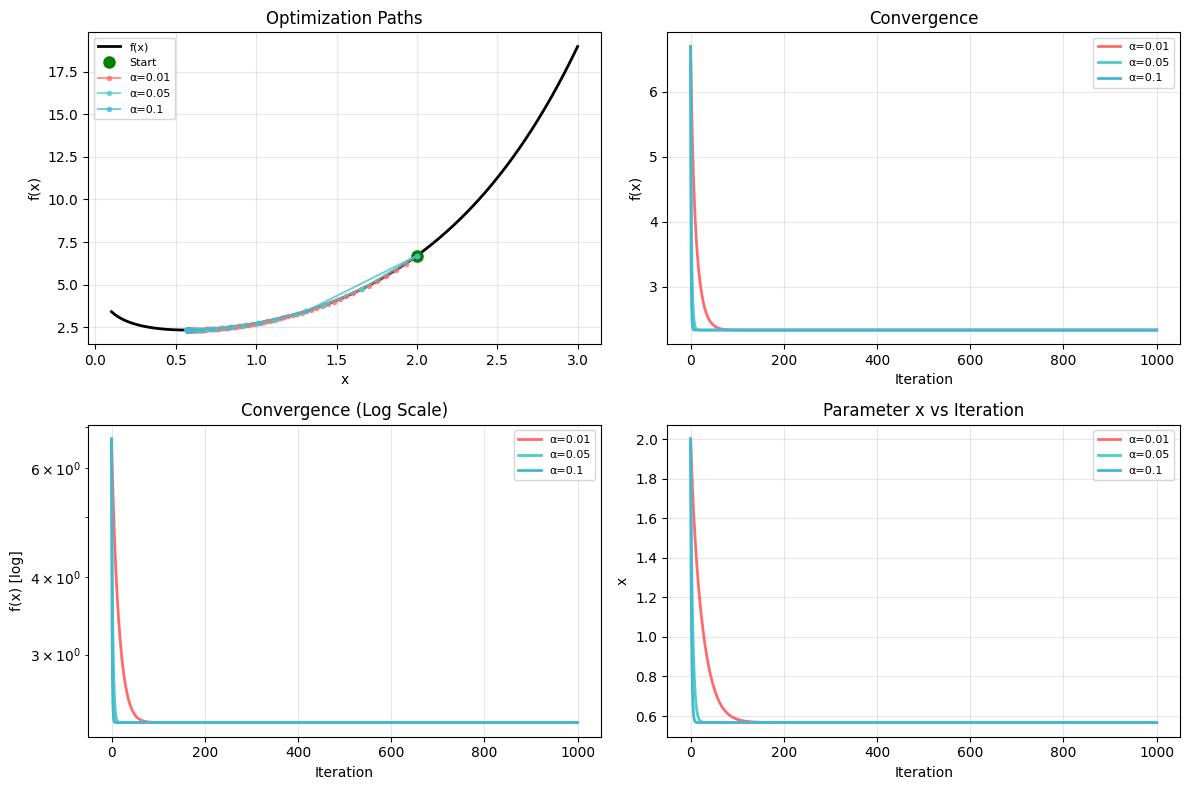

In [14]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
x_range = np.linspace(0.1, 3, 500)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Optimization paths on function curve
axes[0, 0].plot(x_range, objective_function(x_range), 'k-', linewidth=2, label='f(x)')
axes[0, 0].plot(x_initial, objective_function(x_initial), 'go', markersize=8, label='Start')
for i, lr in enumerate(learning_rates):
    x_hist = results[lr]['x_history']
    f_hist = results[lr]['f_history']
    axes[0, 0].plot(x_hist, f_hist, 'o-', color=colors[i], markersize=3, alpha=0.7, label=f'α={lr}')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('f(x)')
axes[0, 0].set_title('Optimization Paths')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Loss vs iteration
for i, lr in enumerate(learning_rates):
    f_hist = results[lr]['f_history']
    axes[0, 1].plot(f_hist, color=colors[i], linewidth=2, label=f'α={lr}')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('f(x)')
axes[0, 1].set_title('Convergence')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Loss (log scale)
for i, lr in enumerate(learning_rates):
    axes[1, 0].semilogy(results[lr]['f_history'], color=colors[i], linewidth=2, label=f'α={lr}')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('f(x) [log]')
axes[1, 0].set_title('Convergence (Log Scale)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: x value over iterations
for i, lr in enumerate(learning_rates):
    axes[1, 1].plot(results[lr]['x_history'], color=colors[i], linewidth=2, label=f'α={lr}')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('x')
axes[1, 1].set_title('Parameter x vs Iteration')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6: Convergence Summary

In [15]:
print(f"{'α':<8} {'Final x':<14} {'Final f(x)':<14} {'Final gradient':<14}")
print("-" * 50)
for lr in learning_rates:
    x_hist = results[lr]['x_history']
    f_hist = results[lr]['f_history']
    grad = gradient(x_hist[-1])
    print(f"{lr:<8} {x_hist[-1]:<14.6f} {f_hist[-1]:<14.6f} {grad:<14.8f}")

print()
print("Observations:")
print("- Smaller α (0.01): slower but stable convergence")
print("- Larger α (0.1): faster convergence but may overshoot")
print("- All converge to the same minimum (gradient ≈ 0)")

α        Final x        Final f(x)     Final gradient
--------------------------------------------------
0.01     0.567143       2.330366       0.00000000    
0.05     0.567143       2.330366       0.00000000    
0.1      0.567143       2.330366       0.00000000    

Observations:
- Smaller α (0.01): slower but stable convergence
- Larger α (0.1): faster convergence but may overshoot
- All converge to the same minimum (gradient ≈ 0)


## Section 7: Different Starting Points

Since $f(x) = e^x - \log(x)$ is convex, all starting points converge to the same minimum.

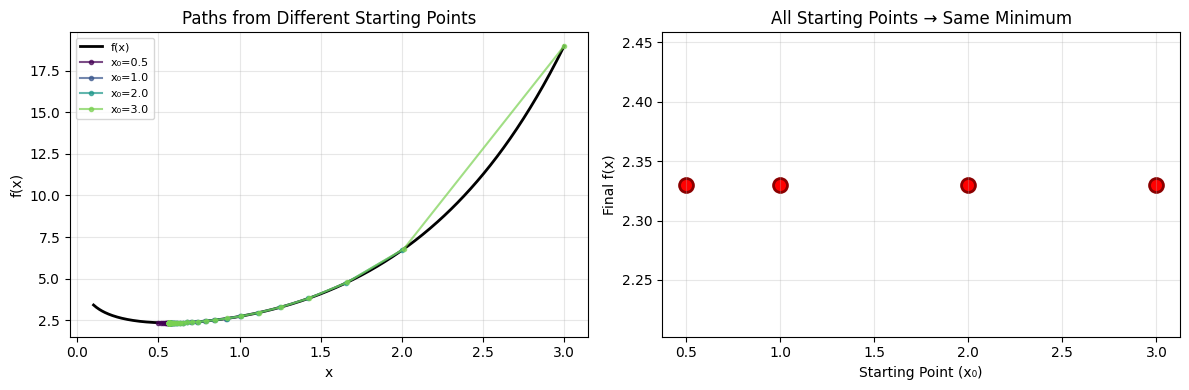

All starting points converge to the same optimal solution.
Final x values: ['0.5671', '0.5671', '0.5671', '0.5671']


In [16]:
initial_points = [0.5, 1.0, 2.0, 3.0]
lr = 0.05

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot paths on function curve
ax1.plot(x_range, objective_function(x_range), 'k-', linewidth=2, label='f(x)')
colors_sp = plt.cm.viridis(np.linspace(0, 0.8, len(initial_points)))

final_x_vals, final_f_vals = [], []
for pt, c in zip(initial_points, colors_sp):
    xh, fh = gradient_descent(pt, lr, num_iterations, gradient, objective_function)
    ax1.plot(xh, fh, 'o-', color=c, markersize=3, alpha=0.7, label=f'x₀={pt}')
    final_x_vals.append(xh[-1])
    final_f_vals.append(fh[-1])

ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Paths from Different Starting Points')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Final values
ax2.scatter(initial_points, final_f_vals, s=100, c='red', edgecolors='darkred', linewidth=2)
ax2.set_xlabel('Starting Point (x₀)')
ax2.set_ylabel('Final f(x)')
ax2.set_title('All Starting Points → Same Minimum')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("All starting points converge to the same optimal solution.")
print(f"Final x values: {[f'{x:.4f}' for x in final_x_vals]}")

## Section 8: Multi-Modal Function

$f(x) = \sin(x) + 0.1x$ has **multiple local minima**. Gradient descent may converge to different minima depending on the starting point.

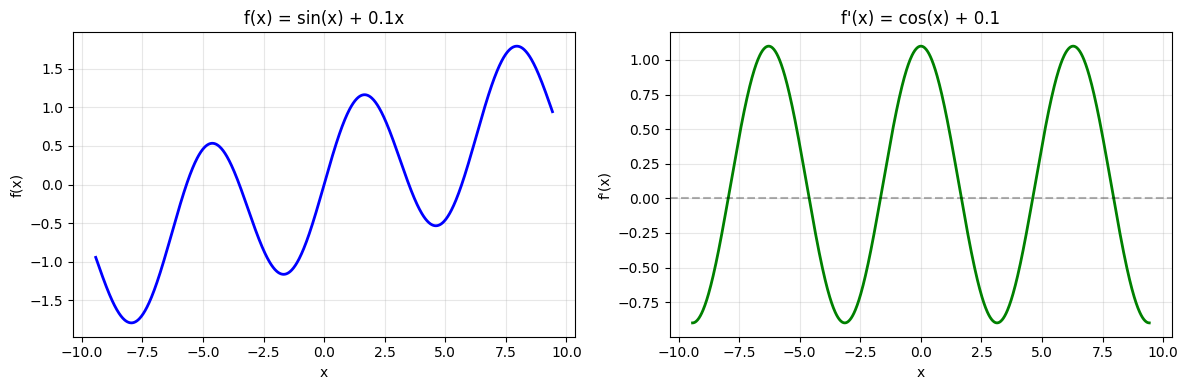

In [17]:
def multimodal_function(x):
    """f(x) = sin(x) + 0.1x"""
    return np.sin(x) + 0.1 * x

def multimodal_gradient(x):
    """f'(x) = cos(x) + 0.1"""
    return np.cos(x) + 0.1

# Visualize the function and its gradient
x_multi = np.linspace(-3 * np.pi, 3 * np.pi, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x_multi, multimodal_function(x_multi), 'b-', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('f(x) = sin(x) + 0.1x')
ax1.grid(True, alpha=0.3)

ax2.plot(x_multi, multimodal_gradient(x_multi), 'g-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")
ax2.set_title("f'(x) = cos(x) + 0.1")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
## Section 9: GD on Multi-Modal Function from Different Starting Points

x₀= -8 → final x=-7.9541, f(x)=-1.7904
x₀= -5 → final x=-7.9541, f(x)=-1.7904
x₀= -2 → final x=-1.6710, f(x)=-1.1621
x₀=  0 → final x=-1.6710, f(x)=-1.1621
x₀=  2 → final x= 4.6122, f(x)=-0.5338
x₀=  5 → final x= 4.6122, f(x)=-0.5338
x₀=  8 → final x=10.8954, f(x)= 0.0946


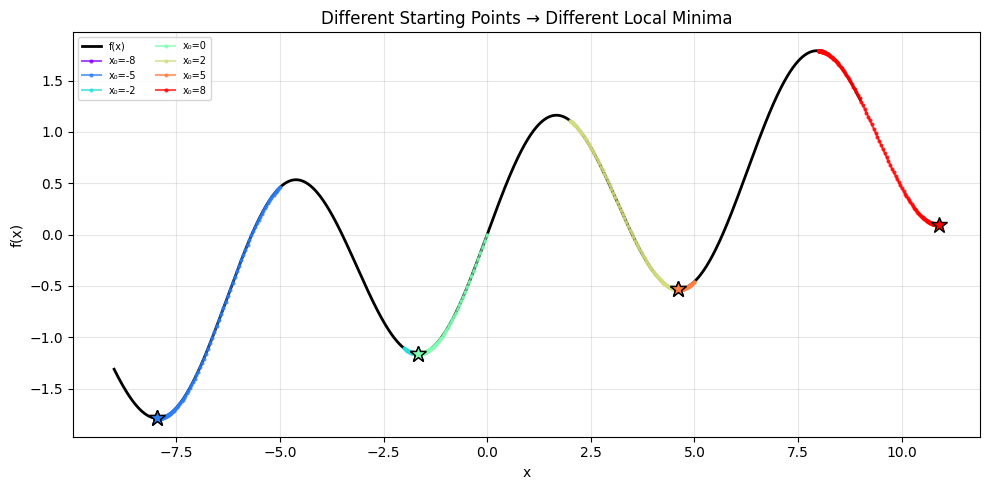


Key takeaway: gradient descent finds the nearest local minimum,
not necessarily the global minimum.


In [19]:
starting_points = [-8, -5, -2, 0, 2, 5, 8]
lr_multi = 0.05
iters_multi = 500

# Run GD from each starting point
multi_results = {}
for sp in starting_points:
    xh, fh = gradient_descent(sp, lr_multi, iters_multi, multimodal_gradient, multimodal_function)
    multi_results[sp] = {'x_history': xh, 'f_history': fh}
    print(f"x₀={sp:3d} → final x={xh[-1]:7.4f}, f(x)={fh[-1]:7.4f}")

# Plot paths
x_viz = np.linspace(-9, 9, 1000)
colors_m = plt.cm.rainbow(np.linspace(0, 1, len(starting_points)))

plt.figure(figsize=(10, 5))
plt.plot(x_viz, multimodal_function(x_viz), 'k-', linewidth=2, label='f(x)')

for sp, c in zip(starting_points, colors_m):
    xh = multi_results[sp]['x_history']
    fh = multi_results[sp]['f_history']
    plt.plot(xh, fh, 'o-', color=c, markersize=2, alpha=0.7, label=f'x₀={sp}')
    plt.plot(xh[-1], fh[-1], '*', color=c, markersize=12, markeredgecolor='black')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Different Starting Points → Different Local Minima')
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Key takeaway: gradient descent finds the nearest local minimum,")
print("not necessarily the global minimum.")